In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/Users/divyeshmedidi/Documents/python programming/ML intro/projects/Mall_Customers.csv")

# Check basic info
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


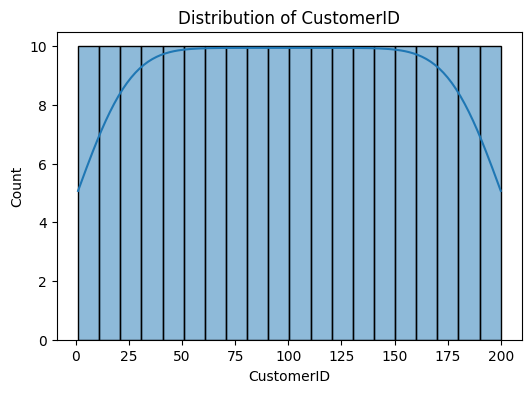

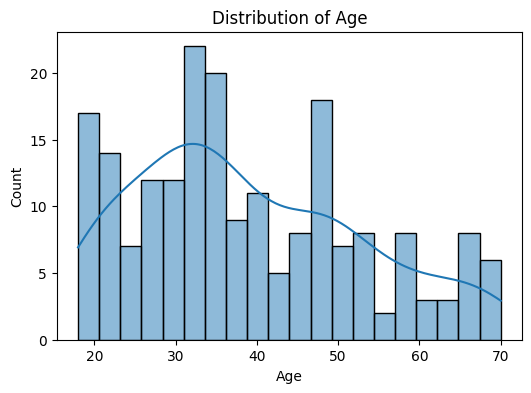

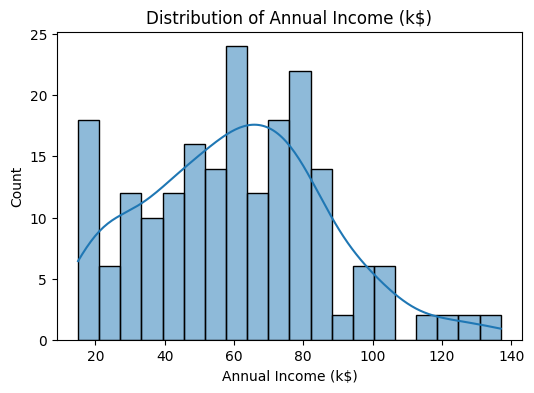

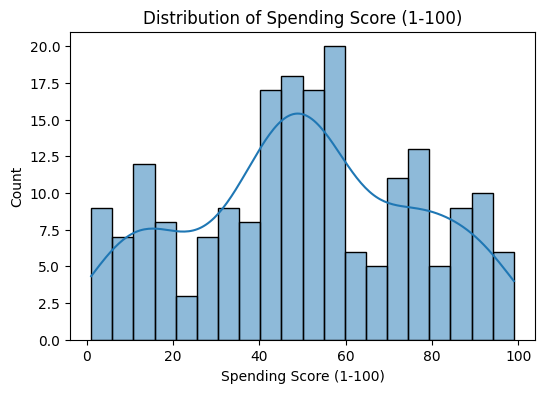

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

# Plot distributions
for feature in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature], bins=20, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler

features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]


scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


df_scaled = pd.DataFrame(scaled_features, columns=features.columns)

print(df_scaled.describe()) 

                Age  Annual Income (k$)  Spending Score (1-100)
count  2.000000e+02        2.000000e+02            2.000000e+02
mean  -1.021405e-16       -2.131628e-16           -1.465494e-16
std    1.002509e+00        1.002509e+00            1.002509e+00
min   -1.496335e+00       -1.738999e+00           -1.910021e+00
25%   -7.248436e-01       -7.275093e-01           -5.997931e-01
50%   -2.045351e-01        3.587926e-02           -7.764312e-03
75%    7.284319e-01        6.656748e-01            8.851316e-01
max    2.235532e+00        2.917671e+00            1.894492e+00


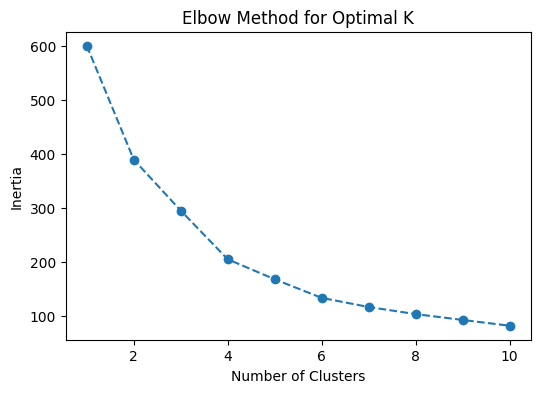

In [4]:
from sklearn.cluster import KMeans


inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [ ]:
k = 5  
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_scaled['Cluster'] = kmeans.fit_predict(df_scaled)

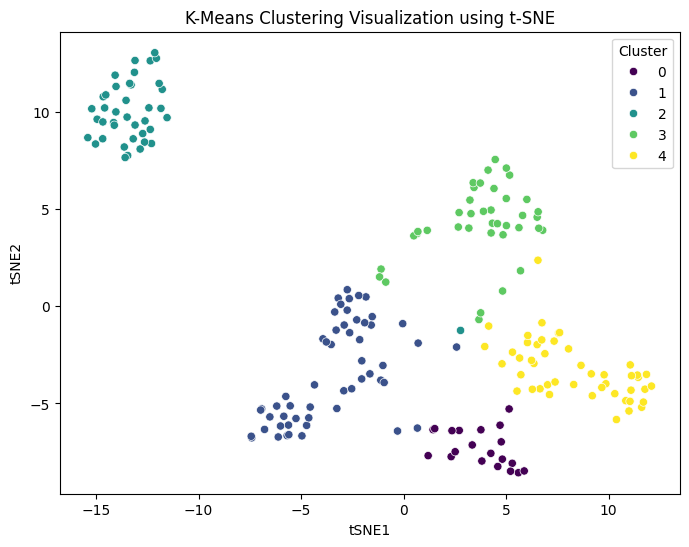

In [6]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_features = tsne.fit_transform(df_scaled.drop('Cluster', axis=1))

df_scaled['tSNE1'] = tsne_features[:, 0]
df_scaled['tSNE2'] = tsne_features[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='tSNE1', y='tSNE2', hue='Cluster', data=df_scaled, palette='viridis')
plt.title('K-Means Clustering Visualization using t-SNE')
plt.show()